### Import libraries

In [49]:
library(ggplot2)
library(scales)
library(gtable)
library(grid)
library(argparse)
options(repr.plot.width = 24, repr.plot.height = 6)

In [47]:
df = read.table("/home/lknq/GitHub/forge/notebook/analysis.txt", header = T, sep = "\t")
head(df, 2)

,Chr,Start,End,dbSNP_Id,Exome,Name,Clinvar,Hom,Het,Total
,<chr>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,chr14,88401213,88401213,rs421262,17,c.1921A>G,Benign,530,73,603
2,chr14,88401219,88401219,.,17,c.1915C>T,.,0,1,1


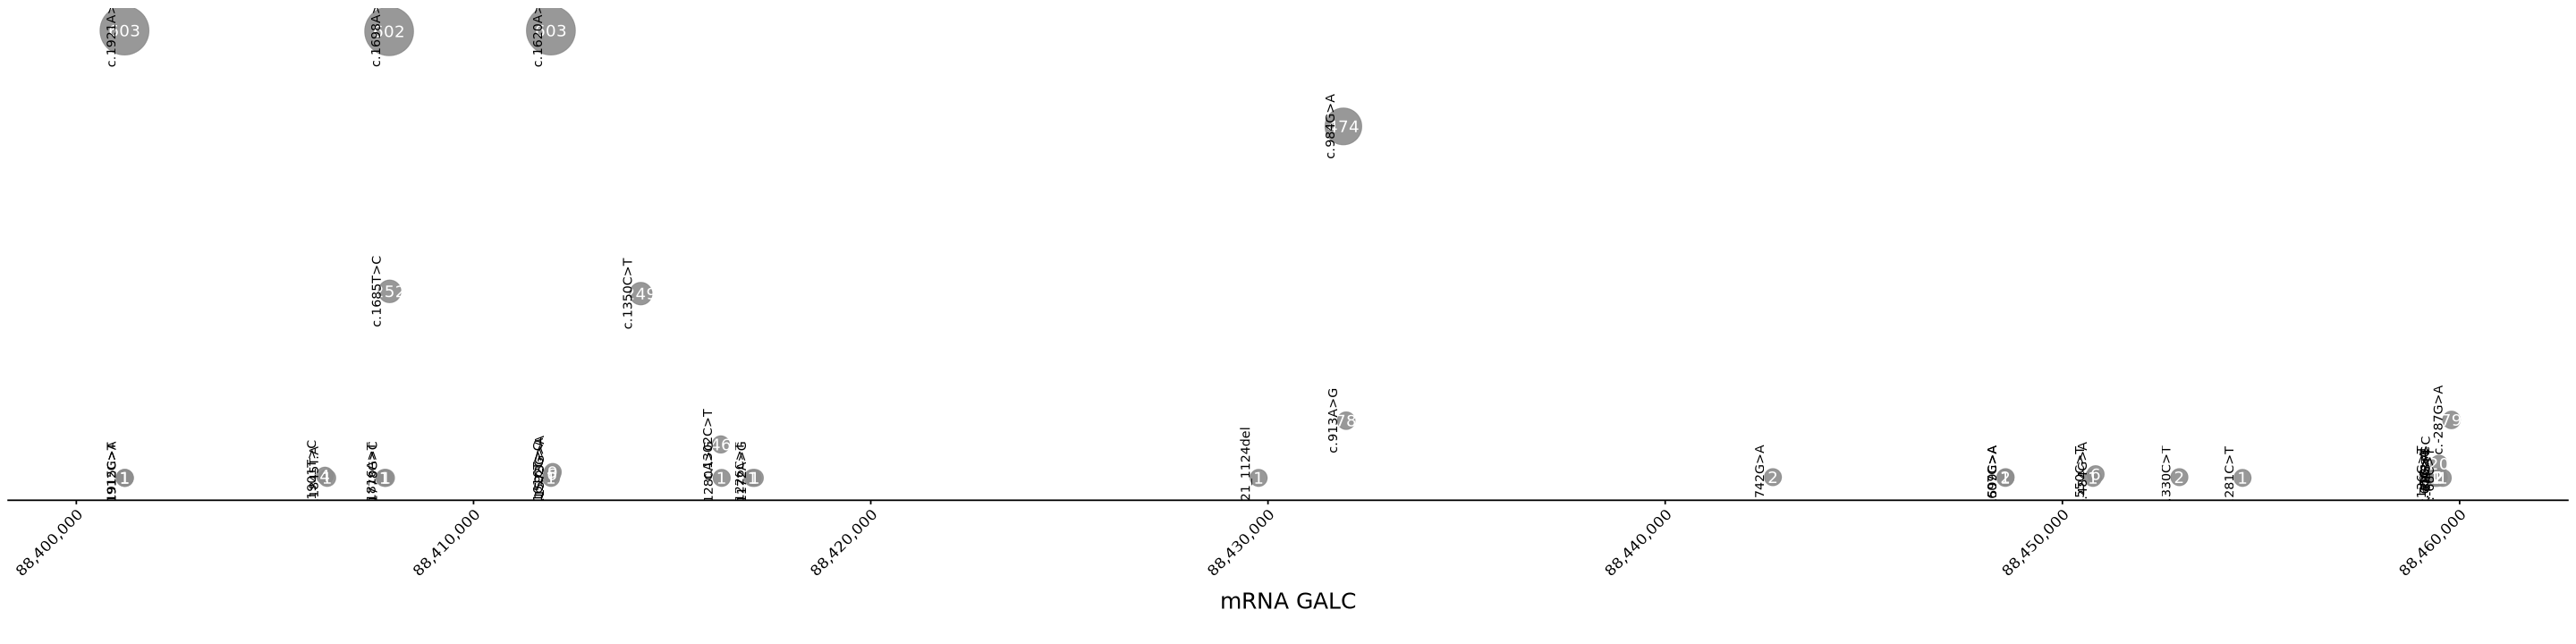

In [54]:

chart = ggplot(
    data=df, 
    aes(x=Start, y=Total)
)

chart = chart + ylab("Coverage") + xlab("mRNA GALC")
chart = chart + scale_x_continuous(labels=comma, breaks = scales::pretty_breaks(n=5))

df$point_size <- scales::rescale(
            46 * (df$Total^2) + 2,
            to = c(5, 15)
        )

chart = chart + geom_point(
            pch=21, 
            color="#8d8d8d", 
            fill="#8d8d8d", 
            size = df$point_size,
            alpha = 0.9,
        ) + scale_size_identity()

chart = chart + geom_text(
    aes(label = round(Total, 1)),
    color = "white",
    # size = 3
)

chart = chart + geom_text(
    aes(label = Name),
    vjust = -1,
    size = 3,
    angle = 90
)

chart = chart + theme_classic()

chart = chart + theme(
    axis.line.y = element_blank(),
    axis.text.y = element_blank(),
    axis.ticks.y = element_blank(),
    axis.title.y = element_blank(),
    
    axis.text.x = element_text(
        size = 10,
        angle = 45, 
        hjust = 1
    ),
    axis.title.x = element_text(
        size = 15,
        margin = margin(t = 15, b = 15)
    ),
)

chart


In [ ]:
ggsave(
    plot = chart, 
    file=file.path("/home/lknq/GitHub/forge/notebook", paste0("Krabe.pdf")), 
    width=24, 
    height=6
)

In [55]:
print(warnings())